# Customer Intent Intelligence
## Notebook 02 — TF-IDF Baseline Models

### Objective

Build lexical baseline classifiers for BANKING77 using:

1. TF-IDF with unigram and bigram features
2. Logistic Regression
3. Linear SVM

Evaluate using:
- Accuracy
- Macro Precision
- Macro Recall
- Macro F1
- Weighted F1
- Confusion Matrix

The test set is reserved for final evaluation.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import joblib

pd.set_option("display.max_colwidth", 200)

sns.set_theme(style="whitegrid")

## 2. Load processed data 

In [2]:
train_df = pd.read_csv("../data/processed/train.csv")
test_df = pd.read_csv("../data/processed/test.csv")

In [3]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

display(train_df.head())

Train shape: (10003, 3)
Test shape: (3080, 3)


,text,processed_text,category
0,I am still waiting on my card?,i am still waiting on my card,card_arrival
1,What can I do if my card still hasn't arrived after 2 weeks?,what can i do if my card still hasn t arrived after weeks,card_arrival
2,I have been waiting over a week. Is the card still coming?,i have been waiting over a week is the card still coming,card_arrival
3,Can I track my card while it is in the process of delivery?,can i track my card while it is in the process of delivery,card_arrival
4,"How do I know if I will get my card, or if it is lost?",how do i know if i will get my card or if it is lost,card_arrival


## 3. Define features and target

In [4]:
X = train_df["processed_text"]
y = train_df["category"]

X_test = test_df["processed_text"]
y_test = test_df["category"]

In [5]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

Training samples: 8002
Validation samples: 2001
Test samples: 3080


## 4. TF-IDF

TF-IDF converts customer queries into numerical feature vectors.

We use:

- Unigrams: individual words
- Bigrams: two-word combinations
- `min_df=2`: ignore extremely rare terms
- `max_df=0.95`: ignore terms appearing in almost every document
- `sublinear_tf=True`: use logarithmic term-frequency scaling 

In [7]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

In [8]:
X_train_tfidf = tfidf.fit_transform(X_train)

X_val_tfidf = tfidf.transform(X_val)

X_test_tfidf = tfidf.transform(X_test)

In [9]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Validation TF-IDF shape:", X_val_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)

print("Number of features:", len(tfidf.get_feature_names_out()))

Training TF-IDF shape: (8002, 8862)
Validation TF-IDF shape: (2001, 8862)
Test TF-IDF shape: (3080, 8862)
Number of features: 8862


In [10]:
feature_names = tfidf.get_feature_names_out()

print(feature_names[:50])

['able' 'able to' 'about' 'about an' 'about atm' 'about days'
 'about direct' 'about disposable' 'about getting' 'about half'
 'about how' 'about it' 'about me' 'about my' 'about ordering'
 'about that' 'about the' 'about these' 'about this' 'about to'
 'about transferring' 'about verifying' 'about week' 'about weeks'
 'about what' 'about your' 'abroad' 'abroad and' 'abroad but' 'abroad for'
 'abroad got' 'abroad that' 'abroad the' 'abroad was' 'absolutely'
 'accept' 'accept any' 'accept cash' 'accept cheques' 'accept for'
 'accept mastercard' 'accept my' 'accept that' 'accept this' 'accept to'
 'acceptable' 'accepted' 'accepted at' 'accepted by' 'accepted for']


## 5. Logistic Regression

In [11]:
lr_model = LogisticRegression(
    C=1.0,
    max_iter=2000,
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [12]:
lr_val_pred = lr_model.predict(X_val_tfidf)

## 6. Evaluation function 

In [13]:
def evaluate_model(y_true, y_pred, model_name):
    
    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro Precision": precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "Macro Recall": recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "Macro F1": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "Weighted F1": f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        )
    }
    
    return results

In [14]:
lr_results = evaluate_model(
    y_val,
    lr_val_pred,
    "TF-IDF + Logistic Regression"
)

lr_results

{'Model': 'TF-IDF + Logistic Regression',
 'Accuracy': 0.8445777111444278,
 'Macro Precision': 0.8530059495398172,
 'Macro Recall': 0.8394794283545519,
 'Macro F1': 0.8413847950694522,
 'Weighted F1': 0.8438733173257258}

In [15]:
print(
    classification_report(
        y_val,
        lr_val_pred,
        zero_division=0
    )
)

                                                  precision    recall  f1-score   support

                           Refund_not_showing_up       0.97      0.91      0.94        32
                                activate_my_card       0.97      0.94      0.95        32
                                       age_limit       1.00      0.91      0.95        22
                         apple_pay_or_google_pay       0.96      0.96      0.96        25
                                     atm_support       0.74      0.82      0.78        17
                                automatic_top_up       1.00      0.84      0.91        25
         balance_not_updated_after_bank_transfer       0.76      0.76      0.76        34
balance_not_updated_after_cheque_or_cash_deposit       0.84      0.86      0.85        36
                         beneficiary_not_allowed       0.81      0.81      0.81        31
                                 cancel_transfer       0.88      0.94      0.91        31
         

## 7. Linear SVM

In [16]:
svm_model = LinearSVC(
    C=1.0,
    random_state=42
)

svm_model.fit(
    X_train_tfidf,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forthe dual coordinate descent (if ``dual=True``). When ``dual=False`` theunderlying implementation of :class:`LinearSVC` is not random and``random_state`` has no effect on the results.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adj

In [17]:
svm_val_pred = svm_model.predict(X_val_tfidf)


In [18]:
svm_results = evaluate_model(
    y_val,
    svm_val_pred,
    "TF-IDF + Linear SVM"
)

svm_results

{'Model': 'TF-IDF + Linear SVM',
 'Accuracy': 0.8810594702648675,
 'Macro Precision': 0.8851953064263108,
 'Macro Recall': 0.8835114224683666,
 'Macro F1': 0.882009815124159,
 'Weighted F1': 0.8808934738275092}

In [19]:
print(
    classification_report(
        y_val,
        svm_val_pred,
        zero_division=0
    )
)

                                                  precision    recall  f1-score   support

                           Refund_not_showing_up       0.91      0.97      0.94        32
                                activate_my_card       0.97      0.94      0.95        32
                                       age_limit       0.95      0.95      0.95        22
                         apple_pay_or_google_pay       1.00      0.96      0.98        25
                                     atm_support       0.88      0.88      0.88        17
                                automatic_top_up       1.00      0.92      0.96        25
         balance_not_updated_after_bank_transfer       0.81      0.76      0.79        34
balance_not_updated_after_cheque_or_cash_deposit       0.89      0.92      0.90        36
                         beneficiary_not_allowed       0.87      0.87      0.87        31
                                 cancel_transfer       1.00      0.97      0.98        31
         

## Compare baselines

In [20]:
results_df = pd.DataFrame([
    lr_results,
    svm_results
])

results_df

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,TF-IDF + Logistic Regression,0.844578,0.853006,0.839479,0.841385,0.843873
1,TF-IDF + Linear SVM,0.881059,0.885195,0.883511,0.882010,0.880893


In [21]:
results_df.round(4)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,TF-IDF + Logistic Regression,0.8446,0.8530,0.8395,0.8414,0.8439
1,TF-IDF + Linear SVM,0.8811,0.8852,0.8835,0.8820,0.8809


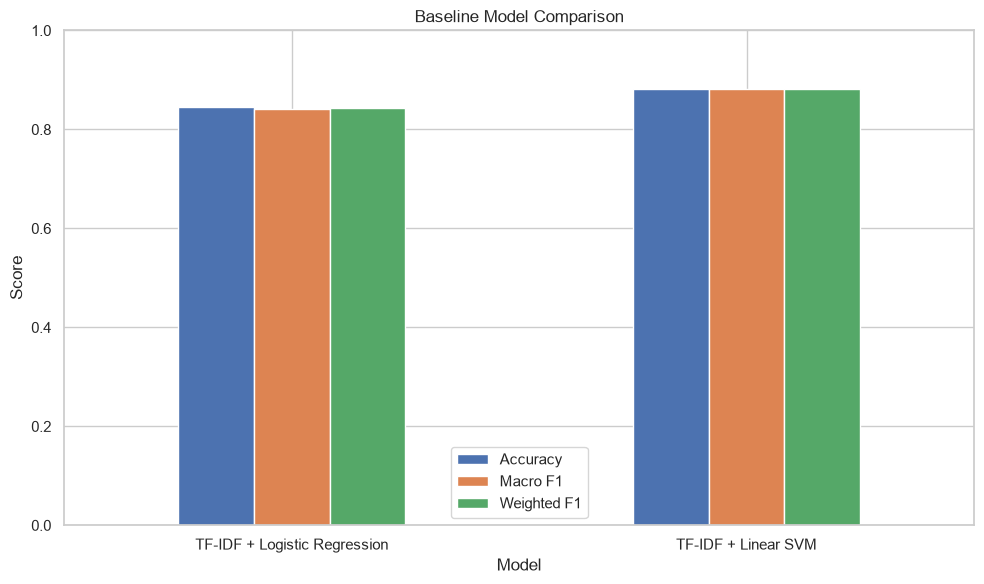

In [22]:
results_plot = results_df.set_index("Model")[
    ["Accuracy", "Macro F1", "Weighted F1"]
]

results_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Baseline Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [23]:
# The set of intents present in the validation split, used to align the
# per-intent F1 tables below.
labels = sorted(y_val.unique())

print("Number of intents in validation split:", len(labels))

lr_report = classification_report(
    y_val,
    lr_val_pred,
    output_dict=True,
    zero_division=0
)

svm_report = classification_report(
    y_val,
    svm_val_pred,
    output_dict=True,
    zero_division=0
)

Number of intents in validation split: 77


In [24]:
intent_f1 = pd.DataFrame({
    "Intent": labels,
    "Logistic Regression F1": [
        lr_report[intent]["f1-score"]
        for intent in labels
    ],
    "SVM F1": [
        svm_report[intent]["f1-score"]
        for intent in labels
    ]
})

intent_f1["Difference"] = (
    intent_f1["SVM F1"]
    - intent_f1["Logistic Regression F1"]
)

intent_f1.sort_values(
    "Difference"
).head(10)

,Intent,Logistic Regression F1,SVM F1,Difference
56,top_up_by_bank_transfer_charge,0.818182,0.760000,-0.058182
13,card_delivery_estimate,0.775510,0.739130,-0.036380
65,transfer_into_account,0.826087,0.800000,-0.026087
45,passcode_forgotten,1.000000,0.976744,-0.023256
31,edit_personal_details,0.979592,0.958333,-0.021259
61,top_up_reverted,0.833333,0.813559,-0.019774
22,change_pin,0.888889,0.869565,-0.019324
67,transfer_timing,0.872727,0.867925,-0.004803
76,wrong_exchange_rate_for_cash_withdrawal,0.903226,0.903226,0.000000
1,activate_my_card,0.952381,0.952381,0.000000


## Best/worst intents

In [25]:
intent_f1.sort_values(
    "Logistic Regression F1"
).head(10)

,Intent,Logistic Regression F1,SVM F1,Difference
11,card_acceptance,0.608696,0.785714,0.177019
72,virtual_card_not_working,0.666667,1.000000,0.333333
59,top_up_failed,0.692308,0.716981,0.024673
62,topping_up_by_card,0.705882,0.809524,0.103641
42,lost_or_stolen_card,0.709677,0.750000,0.040323
44,order_physical_card,0.739130,0.888889,0.149758
38,get_disposable_virtual_card,0.742857,0.864865,0.122008
48,pending_top_up,0.745763,0.758621,0.012858
26,declined_card_payment,0.746269,0.757576,0.011307
54,supported_cards_and_currencies,0.750000,0.807018,0.057018


In [26]:
intent_f1.sort_values(
    "SVM F1"
).head(10)

,Intent,Logistic Regression F1,SVM F1,Difference
59,top_up_failed,0.692308,0.716981,0.024673
13,card_delivery_estimate,0.775510,0.739130,-0.036380
42,lost_or_stolen_card,0.709677,0.750000,0.040323
26,declined_card_payment,0.746269,0.757576,0.011307
48,pending_top_up,0.745763,0.758621,0.012858
56,top_up_by_bank_transfer_charge,0.818182,0.760000,-0.058182
47,pending_cash_withdrawal,0.760000,0.760000,0.000000
27,declined_cash_withdrawal,0.756757,0.782609,0.025852
11,card_acceptance,0.608696,0.785714,0.177019
6,balance_not_updated_after_bank_transfer,0.764706,0.787879,0.023173


## 13. Hyperparameter tuning — Logistic Regression

In [27]:
lr_candidates = [0.1, 1.0, 10.0]

lr_tuning_results = []

for c in lr_candidates:
    
    model = LogisticRegression(
        C=c,
        max_iter=2000,
        random_state=42
    )
    
    model.fit(X_train_tfidf, y_train)
    
    pred = model.predict(X_val_tfidf)
    
    score = f1_score(
        y_val,
        pred,
        average="macro"
    )
    
    lr_tuning_results.append({
        "C": c,
        "Macro F1": score
    })

lr_tuning_df = pd.DataFrame(lr_tuning_results)

lr_tuning_df

,C,Macro F1
0,0.1,0.619436
1,1.0,0.841385
2,10.0,0.873498


In [28]:
best_lr_c = lr_tuning_df.loc[
    lr_tuning_df["Macro F1"].idxmax(),
    "C"
]

best_lr_c

np.float64(10.0)

## 14. Hyperparameter tuning — SVM

In [29]:
svm_candidates = [0.1, 1.0, 10.0]

svm_tuning_results = []

for c in svm_candidates:
    
    model = LinearSVC(
        C=c,
        random_state=42
    )
    
    model.fit(X_train_tfidf, y_train)
    
    pred = model.predict(X_val_tfidf)
    
    score = f1_score(
        y_val,
        pred,
        average="macro"
    )
    
    svm_tuning_results.append({
        "C": c,
        "Macro F1": score
    })

svm_tuning_df = pd.DataFrame(
    svm_tuning_results
)

svm_tuning_df

,C,Macro F1
0,0.1,0.846560
1,1.0,0.882010
2,10.0,0.872536


In [30]:
best_svm_c = svm_tuning_df.loc[
    svm_tuning_df["Macro F1"].idxmax(),
    "C"
]

best_svm_c

np.float64(1.0)

## 15. Train best models

In [31]:
final_tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_full_tfidf = final_tfidf.fit_transform(X)

X_test_final_tfidf = final_tfidf.transform(X_test)

In [32]:
final_lr = LogisticRegression(
    C=best_lr_c,
    max_iter=2000,
    random_state=42
)

final_lr.fit(
    X_full_tfidf,
    y
)

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",np.float64(10.0)
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. D

In [33]:
final_svm = LinearSVC(
    C=best_svm_c,
    random_state=42
)

final_svm.fit(
    X_full_tfidf,
    y
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forthe dual coordinate descent (if ``dual=True``). When ``dual=False`` theunderlying implementation of :class:`LinearSVC` is not random and``random_state`` has no effect on the results.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",np.float64(1.0)
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to autom

In [34]:
lr_test_pred = final_lr.predict(
    X_test_final_tfidf
)

svm_test_pred = final_svm.predict(
    X_test_final_tfidf
)

## Final evaluation

In [35]:
final_lr_results = evaluate_model(
    y_test,
    lr_test_pred,
    "TF-IDF + Logistic Regression"
)

final_svm_results = evaluate_model(
    y_test,
    svm_test_pred,
    "TF-IDF + Linear SVM"
)

final_results = pd.DataFrame([
    final_lr_results,
    final_svm_results
])

# Validation Macro F1 from the tuning step above. Model selection in the later
# notebooks uses this column, so the test set stays a genuine hold-out.
final_results.insert(
    1,
    "Validation Macro F1",
    [
        lr_tuning_df["Macro F1"].max(),
        svm_tuning_df["Macro F1"].max()
    ]
)

final_results.round(4)

,Model,Validation Macro F1,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,TF-IDF + Logistic Regression,0.8735,0.8912,0.8958,0.8912,0.8915,0.8915
1,TF-IDF + Linear SVM,0.8820,0.8906,0.8944,0.8906,0.8906,0.8906


## 16. Final classification reports

In [36]:
print("LOGISTIC REGRESSION")
print(
    classification_report(
        y_test,
        lr_test_pred,
        zero_division=0
    )
)

LOGISTIC REGRESSION
                                                  precision    recall  f1-score   support

                           Refund_not_showing_up       0.97      0.95      0.96        40
                                activate_my_card       0.95      0.95      0.95        40
                                       age_limit       0.98      1.00      0.99        40
                         apple_pay_or_google_pay       1.00      1.00      1.00        40
                                     atm_support       0.92      0.90      0.91        40
                                automatic_top_up       1.00      0.93      0.96        40
         balance_not_updated_after_bank_transfer       0.63      0.78      0.70        40
balance_not_updated_after_cheque_or_cash_deposit       0.93      0.95      0.94        40
                         beneficiary_not_allowed       0.88      0.93      0.90        40
                                 cancel_transfer       0.95      0.95      0.95

In [37]:
print("LINEAR SVM")
print(
    classification_report(
        y_test,
        svm_test_pred,
        zero_division=0
    )
)

LINEAR SVM
                                                  precision    recall  f1-score   support

                           Refund_not_showing_up       0.95      0.95      0.95        40
                                activate_my_card       0.97      0.95      0.96        40
                                       age_limit       0.95      1.00      0.98        40
                         apple_pay_or_google_pay       1.00      1.00      1.00        40
                                     atm_support       0.90      0.90      0.90        40
                                automatic_top_up       1.00      0.97      0.99        40
         balance_not_updated_after_bank_transfer       0.67      0.75      0.71        40
balance_not_updated_after_cheque_or_cash_deposit       0.90      0.93      0.91        40
                         beneficiary_not_allowed       0.93      0.95      0.94        40
                                 cancel_transfer       0.93      0.95      0.94        4

## 17. Save models

In [38]:
joblib.dump(
    final_tfidf,
    "../models/tfidf_vectorizer.pkl"
)

joblib.dump(
    final_lr,
    "../models/logistic_regression.pkl"
)

joblib.dump(
    final_svm,
    "../models/linear_svm.pkl"
)

['../models/linear_svm.pkl']

## 18. save results

In [39]:
import os
os.makedirs(
    "../reports/results",
    exist_ok=True
)

final_results.to_csv(
    "../reports/results/baseline_results.csv",
    index=False
)

## 19. Save predictions for Notebook 04

In [40]:
error_analysis_df = test_df[
    ["text", "category"]
].copy()

error_analysis_df["lr_prediction"] = lr_test_pred
error_analysis_df["svm_prediction"] = svm_test_pred

error_analysis_df["lr_correct"] = (
    error_analysis_df["category"]
    == error_analysis_df["lr_prediction"]
)

error_analysis_df["svm_correct"] = (
    error_analysis_df["category"]
    == error_analysis_df["svm_prediction"]
)

In [41]:
error_analysis_df.to_csv(
    "../reports/results/baseline_predictions.csv",
    index=False
)

# Conclusion

Two lexical baseline models were evaluated using the same TF-IDF
representation:

1. Logistic Regression
2. Linear SVM

TF-IDF used unigram and bigram features.

The models were evaluated using:

- Accuracy
- Macro Precision
- Macro Recall
- Macro F1
- Weighted F1

A validation split was used for hyperparameter selection, while the
original test set was reserved for final evaluation.

The trained TF-IDF vectorizer and baseline models were saved for
downstream error analysis and application development.

The next notebook introduces sentence embeddings to compare lexical
representations against semantic representations.